# HMR backends: CameraHMR · BLADE · SHAPY

Three single-image human-mesh-recovery methods behind one **polymorphic interface**, and the
figures they produce. Setup details & gated files: see `docs/setup/HMR_BACKENDS_SETUP.md`.

| Backend | Paper | Body model | Strength | conda env |
|---|---|---|---|---|
| **CameraHMR** | CVPR'25 | SMPL | multi-person crowds; SOTA shape (SSP-3D 11.6 mm) | `camerahmr` |
| **BLADE** | CVPR'25 (NVlabs) | SMPL-X | close-range single subject; true perspective camera (focal + 3D translation) | `blade_env` |
| **SHAPY** | CVPR'22 | SMPL-X | semantic/metric body shape | `shapy` |

**Why subprocess-per-env:** the three repos have incompatible deps (torch/CUDA/mmcv), so they
can't share one Python process. Each backend is invoked via `conda run -n <env> python <runner>`
and reduces its native output to one normalized schema; a single env-agnostic compositor renders
and tiles them.

**Runs from a Windows *or* a WSL kernel.** The tooling detects the OS: on Windows the registry,
the renderer, and the score/teaser scripts transparently bounce into the WSL conda envs (`wsl …`)
with `C:\ → /mnt/c` path translation, while this kernel just orchestrates and displays. So you can
open this in VS Code on the default Windows Python kernel and Run All. (A WSL kernel also works.)

In [3]:
import os, sys, subprocess
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# repo root (walk up to pyproject.toml) -> works from a Windows OR a WSL/Linux kernel
REPO = os.path.abspath(os.getcwd())
while REPO != os.path.dirname(REPO) and not os.path.exists(os.path.join(REPO, "pyproject.toml")):
    REPO = os.path.dirname(REPO)
sys.path.insert(0, os.path.join(REPO, 'tools'))
sys.path.insert(0, os.path.join(REPO, 'tools', 'smplx'))
import schema, render                 # normalized contract + shared renderer (render bridges to WSL on Windows)
from backends import REGISTRY         # polymorphic registry: each backend runs in its WSL conda env, even from a Windows kernel
for b in REGISTRY.values():
    print(f'{b.name:10s} label={b.label:10s} env={b.env:10s} runner={b.runner}')

# SSP-3D images shipped in the repo (reachable on Windows AND, as /mnt/c, inside WSL)
SSP = os.path.join(REPO, 'datasets', 'SSP-3D', 'ssp_3d')
stems = [
    'beach_handball_vid_001_clip_000_person_001_frame_000007',
    'gymnastics_vid_005_clip_002_person_001_frame_000071',
    'powerlifting_vid_011_clip_000_person_001_frame_000021',
]
images = [os.path.join(SSP, 'images', s + '.png') for s in stems]
stem = stems[0]


def show(img, title=None, figsize=(7,7)):
    plt.figure(figsize=figsize); plt.imshow(img); plt.axis('off')
    if title: plt.title(title)
    plt.show()

camerahmr  label=CameraHMR  env=camerahmr  runner=tools/hmr/camerahmr/run_camerahmr.py
blade      label=BLADE      env=blade_env  runner=tools/hmr/blade/run_blade.py


## 1. CameraHMR — multi-person SMPL geometry
`REGISTRY['camerahmr'].run(images, out)` shells into the `camerahmr` env, detects every person,
and writes one `schema.npz` per image (per-person camera-space vertices + faces + focal). Here we
load a precomputed result and render it with the shared renderer.

using cached CameraHMR + cropped BLADE outputs
image beach_handball_vid_001_clip_000_person_001_frame_000007.png | size 512 x 512 | focal 1135.0 px | people 3 | verts (6890, 3)


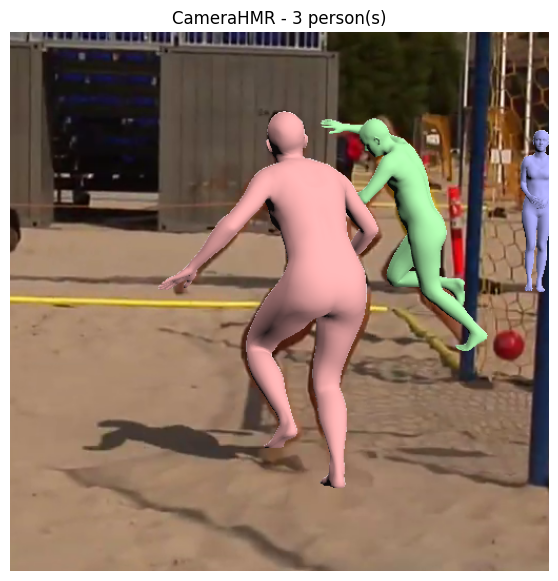

In [4]:
work = os.path.join(REPO, 'runs', 'nb_hmr')
expected = []
for s in stems:
    expected.append(os.path.join(work, 'camerahmr', s + '.npz'))
    expected.append(os.path.join(work, 'blade', s + '.overlay.png'))
if all(os.path.exists(p) for p in expected):
    print('using cached CameraHMR + cropped BLADE outputs')
else:
    for key in ('camerahmr', 'blade'):
        REGISTRY[key].run(images, work)

r = schema.load(os.path.join(work, 'camerahmr', stem + '.npz'))
src_img = os.path.join(SSP, 'images', stem + '.png')   # repo-local source (npz may store a foreign abs path)
print('image', os.path.basename(src_img), '| size', r['img_w'], 'x', r['img_h'],
      '| focal', round(r['focal'], 1), 'px | people', len(r['people']), '| verts', r['people'][0].shape)
bg = np.array(Image.open(src_img).convert('RGB'))
overlay = render.render_overlay(r['people'], r['faces'], r['focal'], r['img_w'], r['img_h'], bg_rgb=bg)
show(overlay, f"CameraHMR - {len(r['people'])} person(s)")


## 2. BLADE -> cropped single-subject SMPL-X + recovered perspective camera
BLADE recovers an SMPL-X mesh + full perspective camera. The registry first crops each frame to the
largest axis-aligned box that contains the target subject while excluding other detected subjects;
the crop is asymmetric when that keeps more useful image area. The runner (`run_blade.py`, all images
in **one model load**) composites BLADE's mesh onto that BLADE input and marks the subject with a
**blue box** by default (`--mark outline` keeps the older contour style), saving `<stem>.overlay.png`.


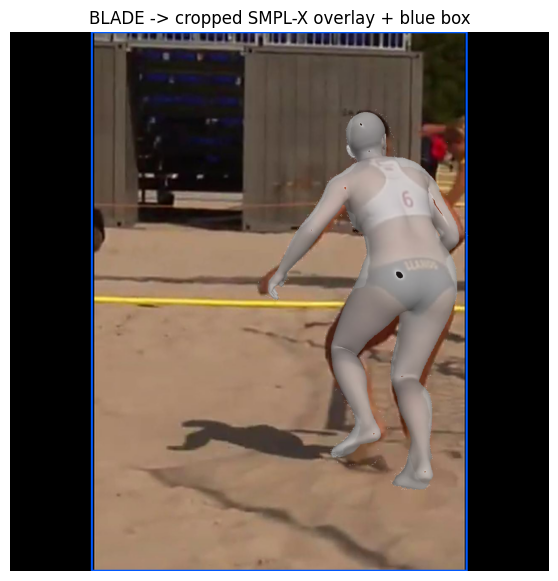

In [5]:

blade_png = os.path.join(REPO, 'runs', 'nb_hmr', 'blade', stem + '.overlay.png')
show(np.array(Image.open(blade_png).convert('RGB')), 'BLADE -> cropped SMPL-X overlay + blue box')



## 3. Side-by-side scene comparison (rows = methods, cols = images)
`tools/smplx/plots.py comparison` tiles the freshly regenerated `runs/nb_hmr` backend outputs. The
BLADE row uses the cropped single-subject inputs and blue boxes.


saved /mnt/c/Users/Clint/OneDrive/Desktop/meshmap/runs/HMR_COMPARE.png  (3 rows x 3 cols)


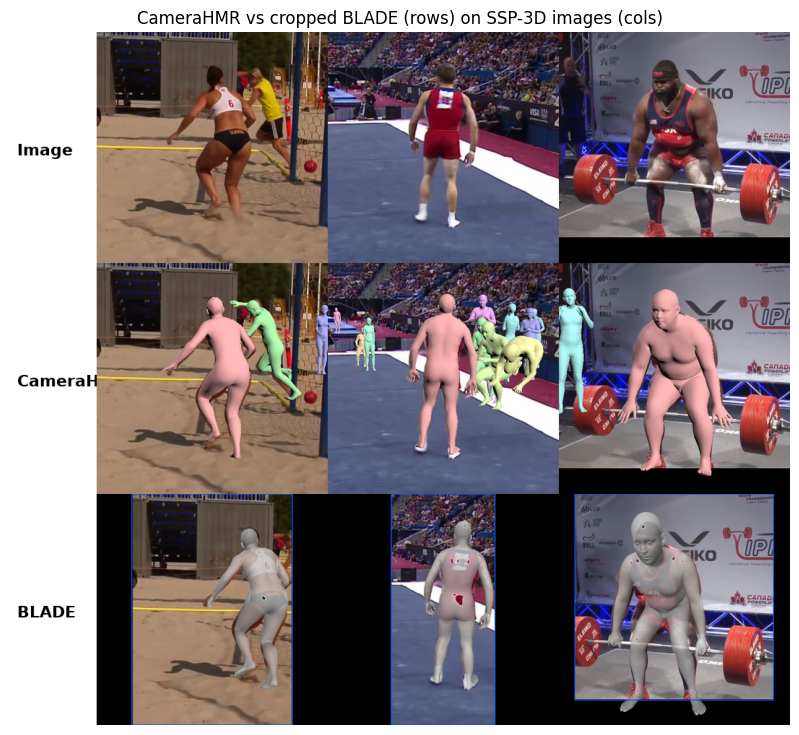

In [6]:

out_cmp = os.path.join(REPO, 'runs', 'HMR_COMPARE.png')
p = subprocess.run([sys.executable, os.path.join(REPO, 'tools', 'smplx', 'plots.py'), 'comparison',
                    '--images', *images, '--backends', 'camerahmr', 'blade',
                    '--work', os.path.join(REPO, 'runs', 'nb_hmr'), '--skip-run', '--out', out_cmp],
                   capture_output=True, text=True)
print((p.stdout + p.stderr).strip()[-400:])
show(np.array(Image.open(out_cmp).convert('RGB')),
     'CameraHMR vs cropped BLADE (rows) on SSP-3D images (cols)', figsize=(13,9))


## 4. SHAPY-style body-SHAPE teaser (all three methods)
Per subject: `Input | Ground truth | SHAPY | CameraHMR | BLADE`, each predicted mesh colored by
**per-vertex error to the GT body surface** (mm, 0-50), in a canonical A-pose. Point-to-surface
distance is topology-agnostic, so SMPL (CameraHMR) and SMPL-X (SHAPY, BLADE) are directly
comparable; **every vertex (incl. hands/face) is colored**, errors above 50 mm clamp to the top
color (no grey). Subjects are chosen by **farthest-point sampling in shape space** for body-type
diversity. Predictions: `runs/{SHAPY,BLADE}_ssp3d.npz`, `runs/CAMERAHMR_ssp3d.npz`.

using cached cropped-BLADE diverse teaser


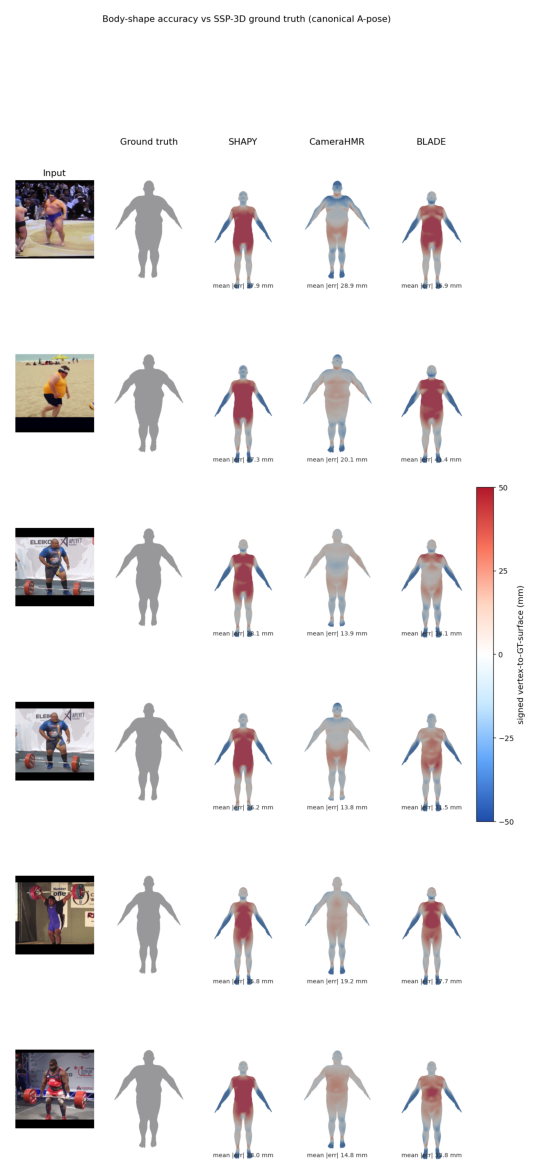

In [7]:

out = os.path.join(REPO, 'runs', 'SHAPY_TEASER.png')
if os.path.exists(out):
    print('using cached cropped-BLADE diverse teaser')
else:
    p = subprocess.run([sys.executable, os.path.join(REPO,'tools','hmr','shapy','plots.py'),
                        '--methods','SHAPY','CameraHMR','BLADE','--n','6','--out',out,
                        '--blade-npz', os.path.join(REPO, 'runs', 'BLADE_ssp3d_crop.npz')],
                       capture_output=True, text=True)
    print((p.stdout + p.stderr).strip()[-400:])
show(np.array(Image.open(out).convert('RGB')), figsize=(13,15))


## 4b. Skinny-only panel
The same teaser, but subjects restricted to the **skinniest builds** (smallest body volume / height³)
— the lean body types the diverse panel under-samples. The diverse panel above is kept as-is.

using cached cropped-BLADE skinny teaser


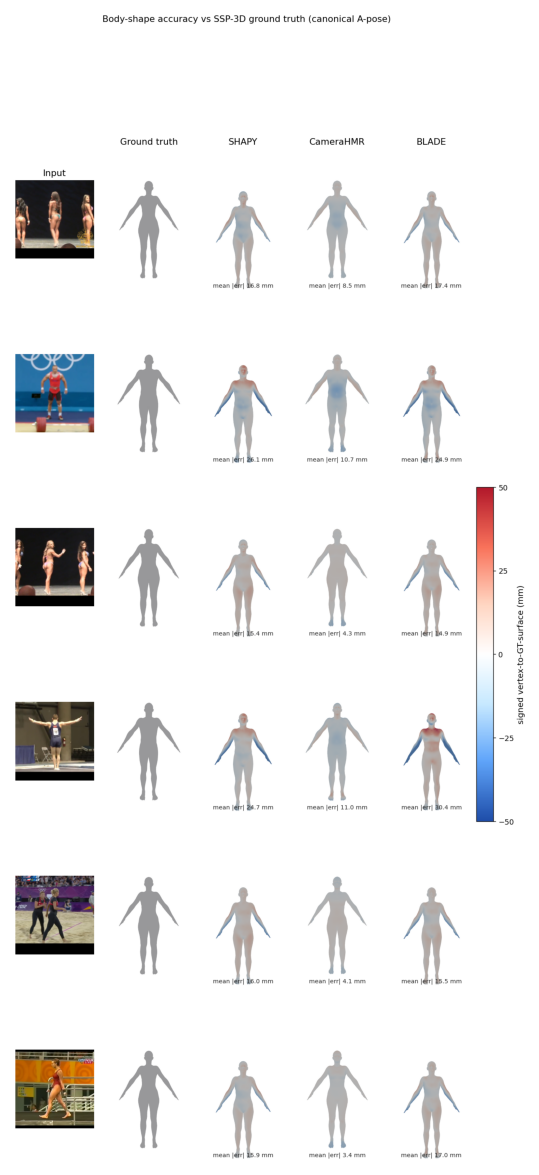

In [8]:

out_s = os.path.join(REPO, 'runs', 'SHAPY_TEASER_skinny.png')
if os.path.exists(out_s):
    print('using cached cropped-BLADE skinny teaser')
else:
    p = subprocess.run([sys.executable, os.path.join(REPO,'tools','hmr','shapy','plots.py'),
                        '--skinny','--methods','SHAPY','CameraHMR','BLADE','--n','6','--out',out_s,
                        '--blade-npz', os.path.join(REPO, 'runs', 'BLADE_ssp3d_crop.npz')],
                       capture_output=True, text=True)
    print((p.stdout + p.stderr).strip()[-400:])
show(np.array(Image.open(out_s).convert('RGB')), figsize=(13,15))


## 5. Per-person geometry access (CameraHMR)
Real geometry → measure, texture, fuse, or export each detected person as a mesh.

In [9]:
import trimesh
outdir = os.path.join(REPO,'runs','nb_hmr','meshes'); os.makedirs(outdir, exist_ok=True)
for i, v in enumerate(r['people']):
    fp = os.path.join(outdir, f'{stem}_person{i}.obj')
    trimesh.Trimesh(v, r['faces'], process=False).export(fp)
    print(f'person {i}: {v.shape[0]} verts, depth z={v[:,2].mean():.2f} m -> {os.path.basename(fp)}')

person 0: 6890 verts, depth z=4.99 m -> beach_handball_vid_001_clip_000_person_001_frame_000007_person0.obj
person 1: 6890 verts, depth z=8.11 m -> beach_handball_vid_001_clip_000_person_001_frame_000007_person1.obj
person 2: 6890 verts, depth z=12.27 m -> beach_handball_vid_001_clip_000_person_001_frame_000007_person2.obj



## 6. Capabilities & extending
- **CameraHMR** -> all people, SMPL betas/pose, per-image focal (HumanFoV), camera-space verts. Best for crowds & body **shape**.
- **BLADE** -> cropped primary subject, SMPL-X (hands+face), recovered **focal length + full 3D translation** (metric-ish depth). Best for **close-range / perspective-distorted** shots.
- **SHAPY** -> SMPL-X **shape** from a photo (+keypoints); semantic/metric body attributes.

**Add a 4th method** = one line in `tools/smplx/backends.py` + a runner emitting the schema
(geometry npz) or an overlay PNG:
```python
# Kept-stack extension example:
# REGISTRY['shapy'] = Backend('shapy', 'SHAPY', 'shapy', 'tools/hmr/shapy/run_shapy_ssp3d.py', cwd='~/shapy/regressor')
```
then `tools/smplx/plots.py comparison --backends camerahmr blade hmr2` adds the row automatically.



## 7. Score the dataset (SSP-3D)
Shape accuracy per method: mean vertex-to-GT-**surface** distance (mm, height-scale aligned,
canonical A-pose -- topology-agnostic, so SMPL & SMPL-X are comparable). CameraHMR also gets the
canonical **PVE-T-SC** (ties to the published SSP-3D leaderboard: CameraHMR 11.6, SHAPY 19.2,
STRAPS 15.9). CameraHMR (SOTA shape) wins; BLADE -- a close-range pose/camera method -- is scored on
the cropped SSP-3D subjects currently cached in `runs/BLADE_ssp3d_crop.npz`.
Computed by `tools/benchmark/score_ssp3d.py` -> `runs/SSP3D_SCORES.json`.


using cached cropped-BLADE SSP-3D scores
method      surface mm    +/-   subjects     rows  PVE-T-SC
CameraHMR         9.04   5.01      62/62  311/311     11.47
SHAPY            25.13   9.26      62/62  311/311         -
BLADE            25.29   8.56      62/62   62/311         -


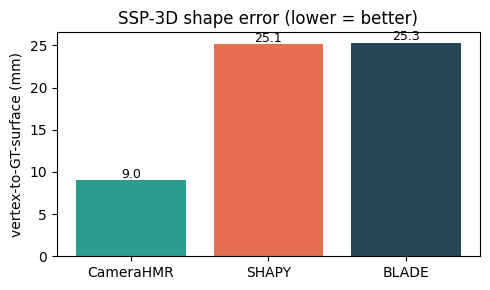

In [10]:

import json
score_path = os.path.join(REPO, 'runs', 'SSP3D_SCORES.json')
if os.path.exists(score_path):
    print('using cached cropped-BLADE SSP-3D scores')
else:
    p = subprocess.run([sys.executable, os.path.join(REPO, 'tools', 'benchmark', 'score_ssp3d.py')],
                       capture_output=True, text=True)
    print((p.stdout + p.stderr).strip()[-600:])
sc = json.load(open(score_path))
print(f"{'method':10s} {'surface mm':>11s} {'+/-':>6s} {'subjects':>10s} {'rows':>8s} {'PVE-T-SC':>9s}")
for n, r in sc.items():
    print(f"{n:10s} {r['surface_err_mm']:11.2f} {r['std']:6.2f} {r.get('subject_coverage', r['coverage']):>10s} {r.get('row_coverage', '-'):>8s} {str(r.get('PVE_T_SC_mm','-')):>9s}")
names = list(sc); vals = [sc[n]['surface_err_mm'] for n in names]
plt.figure(figsize=(5, 3)); plt.bar(names, vals, color=['#2a9d8f', '#e76f51', '#264653'][:len(names)])
plt.ylabel('vertex-to-GT-surface (mm)'); plt.title('SSP-3D shape error (lower = better)')
for i, v in enumerate(vals): plt.text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()
